# Assignment 2: Scalability of Support Vector Machines
## Miles Nordwall, Nathan Nail

In [2]:
import numpy as np
from datetime import datetime

In [3]:
NUM_ITER = 100
ETA = 0.01

#global variable to keep track of runtimes of each model
SVC_IRIS_t = 0.0

### Task #1 Implement LinearSVC

In [5]:
class LinearSVC(object):
    """
    Linear Support Vector Classifier
    Params: 
    eta (float) : Learning rate (between 0.0 and 1.0)
    n_iter (int) : Number of passes over the training dataset.
    random_state (int) : Random number generator seed for random weight initialization.

    Attrs:
    w_ (1d-array) : Weights after fitting with bias absorbed at X[0].
    losses_ (list) : Hinge Loss with L2-regularization loss function values in each epoch.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        self.rand_gen = []
        self.w_initialized = False

    def fit(self, X, y, C=0.1):
        """
        Learns parameters from the training data
        Uses SGD
        Params:
        X {array-like}, shape = [n_examples, n_features]
        Training vectors, where n_examples is the number of examples and n_features is the number of features.
        y (array-like) ,shape = [n_examples]
        Target values.
        C {float} = regularization hyperparameter 

        Returns:
        self : Instance of LinearSVC
        """
        self.losses_ = []
        X = self._initialize_weights(X,X.shape[1])
        c_n = C /X.shape[0]
        
        for _ in range(self.n_iter):
            
            X, y = self._shuffle(X, y)
            epoch_losses = []
            
            for xi, yi in zip(X, y):
                
                y_hat = self.net_input(xi)
                fn_margin = 1 - (yi*y_hat)
                Li = np.maximum(0,fn_margin)

                #gd = self.w_ + c_n * (-yi*xi) #dL/dw
                b_update = 0
                if fn_margin > 0: #case 1
                    gd = self.w_ + c_n * (-yi*xi) #dL/dw
                    b_update = -yi
                else: #case 2
                    gd = self.w_
                epoch_losses.append(Li)
                self.w_ += self.eta* (-gd)
                self.b_ += self.eta* b_update
            avg_loss = np.mean(epoch_losses)
            self.losses_.append(avg_loss)
        return self
        

    
    def _initialize_weights(self, X, m):
        """Initialize weights to small random numbers
        """
        self.b_ = np.float_(0.)
        self.rand_gen = np.random.RandomState(self.random_state)
        self.w_ = self.rand_gen.normal(loc=0.0, scale=0.01,
                                  size=m)
        self.w_initialized = True
        return X
        

    def _update_weights(self, xi, y):
        """Calculate hinge loss then apply GD to L wrt w_"""
        y_hat = self.net_input(xi)
        Li = np.max(0, 1 - (y*y_hat))
        loss = c_n * (Li + (0.5 * (self.w_.shape[0])^2))
        self.w_ += self.w_ + self.eta - loss
        self.b_ += gd
        return loss
        
    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rand_gen.permutation(len(y))
        return X[r], y[r]

    def net_input(self, X): #TODO1 the net_input for svc is w^Tx-b right? unabsorb b?
        """Calculate net input"""
        return np.dot(X, self.w_) - self.b_

    def predict(self, X):
        """Return class label after unit step"""
        return np.sign(self.net_input(X))
    
        

### Task #2 make_classification function
$$\bar{a}^T \bar{x} = b$$
$$\{ \bar{x} \in \mathbb{R}^d | \bar{a}^T \bar{x} = b\}$$
$$\text{where } b=0$$

In [7]:
def make_classification(d,n, u=100,seed=1):
    """
    Generates a set of linearly seperable data
    based on a random seperation hyperplane
    d (int) : dimension of set of points
    """
    rand_gen = np.random.RandomState(seed)
    #generate random vector a s.t ||a||=d
    a = rand_gen.random(size=d) #TODO values are between [0-1] btw, is that okay?
    
    #randomly select n samples in range of [-u,u] in each dimension using a gaussian
    
    X = rand_gen.normal(scale=u,size=(n,d))    
    
    #give each xi a label yi 
    y = []
    for j in range(n):
        if a.T.dot(X[j]) < 0: #is this correct?
            yi = -1
        else:
            yi = 1
        y.append(yi)
    Y = np.array(y)

    #TODO make the first 70% training, and the last 30% test
    return X,Y

In [8]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
def plot_decision_regions(X, y, classifier, test_idx=None,
                          resolution=0.02):
    #taken from textbook
    # setup marker generator and color map
    markers = ('o', 'x', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')
    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]
        
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='none', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o',
                    s=100, label='Test set')

/var/folders/q8/dkdmw0695vz4xd77f20xf2h00000gp/T/ipykernel_42853/127553513.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


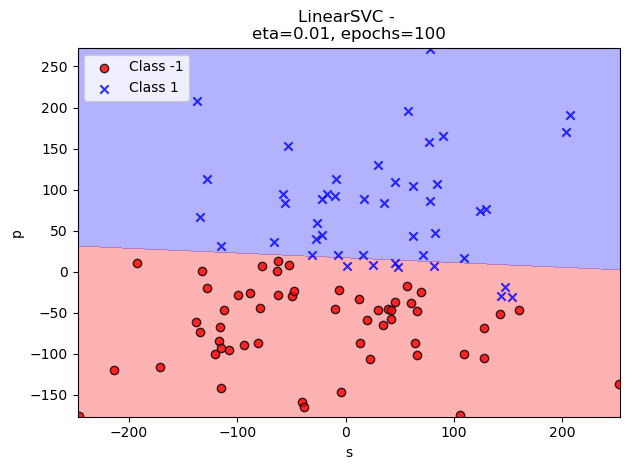

In [9]:
#plotting the decision boundary found for linear svc on the Iris dataset
svc = LinearSVC(n_iter=NUM_ITER, eta=ETA)
X,Y = make_classification(d=2,n=100,u=100,seed=96)

svc_start = datetime.now()
svc.fit(X, Y)
svc_end = datetime.now()
SVC_t = (svc_end - svc_start).total_seconds() *1000

plot_decision_regions(X, Y, classifier=svc)
plt.title(f'LinearSVC - \n'
          f'eta={ETA}, epochs={NUM_ITER}')
plt.xlabel('s')
plt.ylabel('p')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
#plotting the decision boundary found for linear svc on the dataset
svc1 = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_mc_start1 = datetime.now()

X1,Y1 = make_classification(d=10,n=500,u=100,seed=96)
svc1.fit(X1, Y1)

svc_mc_end1 = datetime.now()
SVC_MC1 = (svc_mc_end1 - svc_mc_start1).total_seconds() *1000


In [11]:
#plotting the decision boundary found for linear svc on the dataset
svc2 = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_mc_start2 = datetime.now()

X2,Y2 = make_classification(d=10,n=5000,u=100,seed=96)
svc2.fit(X2, Y2)

svc_mc_end2 = datetime.now()
SVC_MC2 = (svc_mc_end1 - svc_mc_start1).total_seconds() *1000

In [12]:
#plotting the decision boundary found for linear svc on the dataset
svc3 = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_mc_start3 = datetime.now()

X3,Y3 = make_classification(d=10,n=50000,u=100,seed=96)
svc3.fit(X3, Y3)

svc_mc_end3 = datetime.now()
SVC_MC3 = (svc_mc_end3 - svc_mc_start3).total_seconds() *1000

In [13]:
#plotting the decision boundary found for linear svc on the dataset
svc4 = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_mc_start4 = datetime.now()

X4,Y4 = make_classification(d=50,n=500,u=100,seed=96)
svc4.fit(X4, Y4)

svc_mc_end4 = datetime.now()
SVC_MC4 = (svc_mc_end4 - svc_mc_start4).total_seconds() *1000

In [14]:
#plotting the decision boundary found for linear svc on the dataset
svc5 = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_mc_start5 = datetime.now()

X5,Y5 = make_classification(d=50,n=5000,u=100,seed=96)
svc5.fit(X5, Y5)

svc_mc_end5 = datetime.now()
SVC_MC5 = (svc_mc_end5 - svc_mc_start5).total_seconds() *1000

In [15]:
#plotting the decision boundary found for linear svc on the dataset
svc6 = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_mc_start6 = datetime.now()

X6,Y6 = make_classification(d=50,n=50000,u=100,seed=96)
svc6.fit(X6, Y6)

svc_mc_end6 = datetime.now()
SVC_MC6 = (svc_mc_end6 - svc_mc_start6).total_seconds() *1000

In [16]:
#plotting the decision boundary found for linear svc on the dataset
svc7 = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_mc_start7 = datetime.now()

X7,Y7 = make_classification(d=100,n=500,u=100,seed=96)
svc6.fit(X6, Y6)

svc_mc_end7 = datetime.now()
SVC_MC7 = (svc_mc_end7 - svc_mc_start7).total_seconds() *1000

In [17]:
#plotting the decision boundary found for linear svc on the dataset
svc8 = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_mc_start8 = datetime.now()

X8,Y8 = make_classification(d=100,n=5000,u=100,seed=96)
svc6.fit(X8, Y8)

svc_mc_end8 = datetime.now()
SVC_MC8 = (svc_mc_end8 - svc_mc_start8).total_seconds() *1000

In [18]:
#plotting the decision boundary found for linear svc on the dataset
svc9 = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_mc_start9 = datetime.now()

X9,Y9 = make_classification(d=100,n=50000,u=100,seed=96)
svc6.fit(X6, Y6)

svc_mc_end9 = datetime.now()
SVC_MC9 = (svc_mc_end9 - svc_mc_start9).total_seconds() *1000

In [19]:
print(SVC_MC1)
print(svc1.losses_)

print(SVC_MC2)
print(svc2.losses_)

print(SVC_MC3)
print(svc3.losses_)

print(SVC_MC4)
print(svc4.losses_)

print(SVC_MC5)
print(svc5.losses_)

print(SVC_MC6)
print(svc6.losses_)

print(SVC_MC7)
print(svc7.losses_)

print(SVC_MC8)
print(svc8.losses_)

print(SVC_MC9)
print(svc9.losses_)

318.88899999999995
[0.6903090927498775, 0.4507123653504235, 0.46876427187595016, 0.45837848381801477, 0.4489228148705424, 0.45921139787051507, 0.4624703403056963, 0.4554941111887839, 0.46040295490868005, 0.44262613419969715, 0.4620569352658196, 0.4592062935880558, 0.45735196293514424, 0.464460283930331, 0.46217635022859077, 0.46045902328927596, 0.44488172516801994, 0.4618952573838126, 0.45517734730883297, 0.4644623542207612, 0.4681608201205673, 0.45536524402617623, 0.46897541217289873, 0.4628966551952175, 0.44978225817100553, 0.46175857095034123, 0.46291016472980445, 0.4606614362976243, 0.45844158235710697, 0.46294286249916383, 0.4667473107626589, 0.4432125000900205, 0.44486624774985944, 0.4534548255585987, 0.4562415725840448, 0.4552878591839861, 0.46357065957506133, 0.46447388279396484, 0.45570858157574784, 0.4691845481710876, 0.4556693209130483, 0.4406294984073704, 0.45479790770761713, 0.462042474584798, 0.45301331717235666, 0.45624830639134895, 0.4538526734328509, 0.4462237130465729

AttributeError: 'LinearSVC' object has no attribute 'losses_'

In [ ]:
import os
import pandas as pd
s = os.path.join('https://archive.ics.uci.edu', 'ml',
                 'machine-learning-databases',
                 'iris','iris.data')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

X_4 = df.iloc[50:150, [0, 2]].to_numpy()
Y_ref = df.iloc[50:150, 4].to_numpy()

#Y_ref = np.where(Y_ref == 'Iris-setosa',-1,Y_ref)
Y_ref = np.where(Y_ref == 'Iris-versicolor',1,Y_ref)
Y_ref = np.where(Y_ref == 'Iris-virginica',-1,Y_ref)

X_std4 = np.copy(X_4)
X_std4[:,0] = (X_4[:,0] - X_4[:,0].mean()) / X_4[:,0].std()
X_std4[:,1] = (X_4[:,1] - X_4[:,1].mean()) / X_4[:,1].std()

In [ ]:
#plotting the decision boundary found for linear svc on the Iris dataset
svc = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_iris_start = datetime.now()
svc.fit(X_std4, Y_ref)
svc_iris_end = datetime.now()
SVC_IRIS_t = (svc_iris_end - svc_iris_start).total_seconds() *1000

plot_decision_regions(X_std4, Y_ref, classifier=svc)
plt.title(f'LinearSVC - Iris\n'
          f'eta={ETA}, epochs={NUM_ITER}')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()